# Manufacturing Machine Learning Project

## 프로젝트 개요

이 프로젝트는 정형 제조 데이터를 기반으로 설비의 고장 여부를 예측하는 머신러닝 프로젝트이다.

AI4I 2020 Predictive Maintenance Dataset을 기반으로 머신러닝 모델을 학습하여 설비의 정상/고장 여부를 예측하는 이진분류 모델을 구축한다.

## 모델링 목표

- 제조 설비의 고장 여부를 예측한다.
- `failure` 컬럼을 target으로 사용한다.
- 정상 데이터와 고장 데이터의 불균형을 고려한다.
- Logistic Regression을 baseline 모델로 학습한다.
- RandomForest 모델을 학습하고 baseline과 비교한다.
- Accuracy, Precision, Recall, F1-score, ROC-AUC를 사용하여 모델을 평가한다.
- Feature Importance를 통해 주요 원인 feature를 해석한다.

# 0. 환경 준비

데이터 분석과 머신러닝 모델 학습에 필요한 라이브러리를 불러온다.

또한 프로젝트 내에서 사용할 주요 경로를 설정한다.

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
FIGURE_DIR = BASE_DIR / "figures"
REPORT_DIR = BASE_DIR / "reports"
MODEL_DIR = BASE_DIR / "models"

FIGURE_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# 1. 데이터 불러오기

AI4I 2020 Predictive Maintenance Dataset을 불러온다.

데이터 파일은 프로젝트의 `data` 폴더에 저장되어 있으며, 파일명은 `ai4i2020.csv`로 설정한다.

In [187]:
df = pd.read_csv(DATA_DIR / "ai4i2020.csv")

print("데이터 크기:", df.shape)
df.head()

데이터 크기: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 데이터 불러오기 결과

AI4I 2020 Predictive Maintenance Dataset을 정상적으로 불러왔다.

데이터는 제조 설비의 센서값, 제품 유형, 고장 여부, 세부 고장 유형 정보를 포함하고 있다.

이후 단계에서는 고장 여부를 나타내는 `Machine failure` 컬럼을 이진분류 target으로 사용한다.

# 2. 데이터 구조 확인

모델링을 진행하기 전에 데이터의 컬럼, 데이터 타입, 기초 통계량, 결측치 여부를 확인한다.

In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [189]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [190]:
missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_ratio": df.isnull().mean() * 100
})

missing_report

,missing_count,missing_ratio
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


## 데이터 구조 확인 결과

데이터의 전체 행과 컬럼 수, 각 컬럼의 데이터 타입을 확인하였다.

결측치 확인 결과, 모든 컬럼에서 결측치 개수는 0개이며 결측치 비율도 0.0%로 나타났다.  
따라서 이번 모델링 과정에서는 별도의 결측치 대체 또는 제거 작업이 필요하지 않다.

이 데이터는 제품 유형, 온도, 회전 속도, 토크, 공구 마모 시간 등의 feature와 고장 여부 label을 포함하고 있으므로 이진분류 모델링에 사용할 수 있다.

# 3. 컬럼명 정리

모델링 과정에서 컬럼명을 쉽게 사용하기 위해 컬럼명을 간단한 형태로 변경한다.

공백, 대괄호, 단위가 포함된 컬럼명을 snake_case 형식으로 정리한다.

In [191]:
df = df.rename(columns={
    "UDI": "udi",
    "Product ID": "product_id",
    "Type": "type",
    "Air temperature [K]": "air_temp",
    "Process temperature [K]": "process_temp",
    "Rotational speed [rpm]": "rot_speed",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "tool_wear",
    "Machine failure": "failure"
})

sensor_cols = [
    "air_temp",
    "process_temp",
    "rot_speed",
    "torque",
    "tool_wear"
]

df.head()

,udi,product_id,type,air_temp,process_temp,rot_speed,torque,tool_wear,failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [192]:
df.columns

Index(['udi', 'product_id', 'type', 'air_temp', 'process_temp', 'rot_speed',
       'torque', 'tool_wear', 'failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

## 컬럼명 정리 결과

기존 컬럼명은 공백과 단위가 포함되어 있어 코드 작성 시 불편함이 있었다.

따라서 주요 컬럼명을 snake_case 형태로 변경하였다.

이후 모델링에서는 `air_temp`, `process_temp`, `rot_speed`, `torque`, `tool_wear`를 주요 센서 feature로 사용하고, `failure`를 target으로 사용한다.

# 4. 이진분류 문제 정의

이번 프로젝트는 제조 설비의 고장 여부를 예측하는 이진분류 문제이다.

Target 변수는 `failure` 컬럼이다.

- `failure = 0`: 정상
- `failure = 1`: 고장

모델링 전에 target의 분포를 확인하여 데이터 불균형 여부를 점검한다.

In [193]:
failure_count = df["failure"].value_counts()
failure_ratio = df["failure"].value_counts(normalize=True) * 100

print("Failure count")
print(failure_count)

print("\nFailure ratio")
print(failure_ratio)

print(f"\n전체 고장률: {df['failure'].mean() * 100:.2f}%")

Failure count
failure
0    9661
1     339
Name: count, dtype: int64

Failure ratio
failure
0    96.61
1     3.39
Name: proportion, dtype: float64

전체 고장률: 3.39%


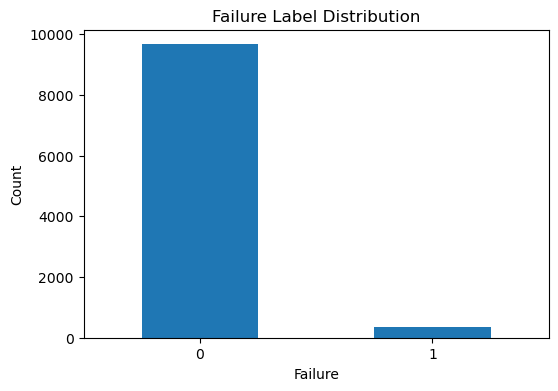

In [194]:
plt.figure(figsize=(6, 4))
failure_count.sort_index().plot(kind="bar")

plt.xlabel("Failure")
plt.ylabel("Count")
plt.title("Failure Label Distribution")
plt.xticks(rotation=0)

plt.savefig(FIGURE_DIR / "failure_label_distribution.png", bbox_inches="tight")
plt.show()

## 이진분류 target 분포 확인 결과

`failure` 컬럼의 분포를 확인한 결과, 정상 데이터가 대부분을 차지하고 고장 데이터는 상대적으로 적게 나타났다.

따라서 이 데이터는 클래스 불균형 문제가 존재한다.

이후 모델 평가에서는 단순 Accuracy만 사용하지 않고, Precision, Recall, F1-score, ROC-AUC를 함께 사용해야 한다.

특히 제조 설비 고장 예측에서는 실제 고장을 정상으로 예측하는 경우가 중요하므로 Recall과 F1-score를 함께 확인한다.

# 5. Feature / Target 분리

머신러닝 모델 학습을 위해 입력 변수인 Feature와 예측 대상인 Target을 분리한다.

Target 변수는 `failure` 컬럼이다.

모델 학습에서 제외할 컬럼은 다음과 같다.

- `udi`: 단순 식별자
- `product_id`: 제품 식별자
- `failure`: 정답 컬럼
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF`: 고장 유형을 나타내는 라벨성 컬럼

특히 `TWF`, `HDF`, `PWF`, `OSF`, `RNF`는 고장 발생 이후의 원인을 나타내는 컬럼이므로,  
고장 여부를 예측하는 모델에 포함하면 데이터 누수가 발생할 수 있다.

In [195]:
drop_cols = [
    "udi",
    "product_id",
    "failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

X = df.drop(columns=drop_cols)
y = df["failure"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (10000, 6)
y shape: (10000,)


,type,air_temp,process_temp,rot_speed,torque,tool_wear
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


## 범주형 변수 인코딩

`type` 컬럼은 제품 유형을 나타내는 범주형 변수이다.

머신러닝 모델은 문자열 데이터를 직접 학습할 수 없기 때문에,  
`type` 컬럼을 One-Hot Encoding 방식으로 변환한다.

In [196]:
X = pd.get_dummies(X, columns=["type"], drop_first=True)

X.head()

,air_temp,process_temp,rot_speed,torque,tool_wear,type_L,type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


In [197]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   air_temp      10000 non-null  float64
 1   process_temp  10000 non-null  float64
 2   rot_speed     10000 non-null  int64  
 3   torque        10000 non-null  float64
 4   tool_wear     10000 non-null  int64  
 5   type_L        10000 non-null  bool   
 6   type_M        10000 non-null  bool   
dtypes: bool(2), float64(3), int64(2)
memory usage: 410.3 KB


## Feature / Target 분리 결과

모델 학습에 사용할 Feature와 Target을 분리하였다.

식별자 컬럼인 `udi`, `product_id`는 제거하였고,  
정답 컬럼인 `failure`도 Feature에서 제외하였다.

또한 `TWF`, `HDF`, `PWF`, `OSF`, `RNF`는 고장 유형을 직접적으로 나타내는 라벨성 컬럼이므로  
데이터 누수를 방지하기 위해 모델 입력 변수에서 제외하였다.

범주형 변수인 `type`은 One-Hot Encoding을 적용하여 숫자형 변수로 변환하였다.

# 6. Train / Valid / Test Split

모델 학습과 평가를 위해 데이터를 train, valid, test로 분리한다.

분리 비율은 다음과 같다.

- train: 70%
- valid: 15%
- test: 15%

데이터가 정상과 고장의 비율이 크게 다른 불균형 데이터이므로,  
`stratify` 옵션을 사용하여 각 데이터셋의 클래스 비율을 비슷하게 유지한다.

In [198]:
from sklearn.model_selection import train_test_split

In [199]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)
print("y_test:", y_test.shape)

X_train: (7000, 7)
X_valid: (1500, 7)
X_test: (1500, 7)
y_train: (7000,)
y_valid: (1500,)
y_test: (1500,)


In [200]:
print("Train target ratio")
print(y_train.value_counts(normalize=True) * 100)

print("\nValid target ratio")
print(y_valid.value_counts(normalize=True) * 100)

print("\nTest target ratio")
print(y_test.value_counts(normalize=True) * 100)

Train target ratio
failure
0    96.614286
1     3.385714
Name: proportion, dtype: float64

Valid target ratio
failure
0    96.6
1     3.4
Name: proportion, dtype: float64

Test target ratio
failure
0    96.6
1     3.4
Name: proportion, dtype: float64


## 데이터 분리 결과

전체 데이터를 train, valid, test로 분리하였다.

train 데이터는 모델 학습에 사용하고,  
valid 데이터는 모델 비교와 선택에 사용하며,  
test 데이터는 최종 성능 평가에 사용한다.

Target 클래스 비율을 확인한 결과, train, valid, test 데이터셋에서 정상과 고장의 비율이 유사하게 유지되었다.

이는 `stratify` 옵션을 적용했기 때문이다.

# 7. 평가 함수 생성

여러 머신러닝 모델을 동일한 기준으로 비교하기 위해 평가 함수를 생성한다.

이번 프로젝트는 정상/고장을 예측하는 이진분류 문제이므로 다음 평가 지표를 사용한다.

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- Classification Report

AI4I 데이터는 정상 데이터가 많고 고장 데이터가 적은 불균형 데이터이므로,  
단순 Accuracy만으로 모델 성능을 판단하면 안 된다.

제조 설비 고장 예측에서는 실제 고장을 얼마나 잘 탐지하는지가 중요하므로  
Recall과 F1-score를 함께 확인한다.

## 평가 지표 해석 기준

각 평가 지표의 의미는 다음과 같다.

- Accuracy: 전체 데이터 중 맞게 예측한 비율
- Precision: 고장이라고 예측한 것 중 실제 고장인 비율
- Recall: 실제 고장 중 모델이 고장으로 잡아낸 비율
- F1-score: Precision과 Recall의 균형 지표
- ROC-AUC: 모델이 정상과 고장을 구분하는 전반적인 성능

불균형 데이터에서는 Accuracy가 높아도 실제 고장을 거의 잡지 못할 수 있다.  
따라서 본 프로젝트에서는 Accuracy뿐만 아니라 Recall, F1-score, ROC-AUC를 함께 확인한다.

In [201]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [202]:
def evaluate_model(model, X_data, y_true):
    y_pred = model.predict(X_data)
    y_proba = model.predict_proba(X_data)[:, 1]
    
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }
    
    return result

## 상세 평가 함수 생성

모델의 성능을 더 자세히 확인하기 위해 Confusion Matrix와 Classification Report를 출력하는 함수를 추가로 생성한다.

이 함수는 모델의 예측 결과를 확인할 때 사용한다.

In [203]:
def print_evaluation_report(model, X_data, y_true):
    y_pred = model.predict(X_data)
    y_proba = model.predict_proba(X_data)[:, 1]
    
    print("Confusion Matrix")
    print(confusion_matrix(y_true, y_pred))
    
    print("\nClassification Report")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))

## 평가 함수 생성 결과

모델별 성능을 동일한 기준으로 비교하기 위해 `evaluate_model()` 함수를 생성하였다.

`evaluate_model()` 함수는 모델, 입력 데이터, 실제 정답을 입력받아  
Accuracy, Precision, Recall, F1-score, ROC-AUC를 계산한다.

또한 `print_evaluation_report()` 함수를 추가로 생성하여  
Confusion Matrix와 Classification Report를 함께 확인할 수 있도록 하였다.

이후 단계에서는 모델을 학습한 뒤, 동일한 평가 함수를 사용하여 모델 성능을 비교한다.

# 8. Baseline 모델 - Logistic Regression

첫 번째 모델로 Logistic Regression을 사용한다.

Logistic Regression은 이진분류 문제에서 가장 기본적으로 사용되는 모델 중 하나이며,  
이후 RandomForest, XGBoost 같은 모델과 비교하기 위한 baseline 모델로 활용할 수 있다.

이번 데이터는 정상 데이터가 많고 고장 데이터가 적은 불균형 데이터이므로  
`class_weight="balanced"` 옵션을 적용한다.

또한 Logistic Regression은 변수의 스케일에 영향을 받을 수 있으므로  
`StandardScaler`를 함께 사용한다.

In [204]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [205]:
log_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [206]:
log_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [207]:
log_valid_result = evaluate_model(log_model, X_valid, y_valid)

log_valid_result

{'Accuracy': 0.8346666666666667,
 'Precision': 0.13653136531365315,
 'Recall': 0.7254901960784313,
 'F1': 0.22981366459627328,
 'ROC-AUC': 0.875018606476407}

In [208]:
print_evaluation_report(log_model, X_valid, y_valid)

Confusion Matrix
[[1215  234]
 [  14   37]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      1449
           1       0.14      0.73      0.23        51

    accuracy                           0.83      1500
   macro avg       0.56      0.78      0.57      1500
weighted avg       0.96      0.83      0.88      1500

ROC-AUC: 0.875018606476407


## Logistic Regression 평가 결과

Logistic Regression 모델을 baseline 모델로 학습하였다.

검증 데이터 기준 성능은 다음과 같다.

- Accuracy: 약 0.835
- Precision: 약 0.137
- Recall: 약 0.725
- F1-score: 약 0.230
- ROC-AUC: 약 0.875

Confusion Matrix를 확인한 결과, 실제 고장 51개 중 37개를 고장으로 예측하였고, 14개는 정상으로 잘못 예측하였다.  
따라서 Logistic Regression 모델은 실제 고장을 비교적 많이 탐지하는 편이지만, 정상 데이터를 고장으로 잘못 예측하는 경우도 많았다.

특히 Precision이 낮고 Recall이 높은 결과가 나타났는데, 이는 `class_weight="balanced"` 옵션으로 인해 모델이 소수 클래스인 고장을 더 적극적으로 예측했기 때문으로 해석할 수 있다.

제조 설비 고장 예측에서는 고장을 놓치지 않는 것이 중요하므로 Recall이 높은 점은 긍정적이다.  
그러나 정상 설비를 고장으로 잘못 판단하는 경우가 많아 Precision과 F1-score는 낮게 나타났다.

ROC-AUC는 약 0.875로 나타나, 모델의 정상/고장 구분 능력은 baseline 모델로서 의미 있는 수준이라고 볼 수 있다.

이후 RandomForest 모델을 학습하여 Logistic Regression baseline과 성능을 비교한다.

# 9. RandomForest 모델

두 번째 모델로 RandomForest를 학습한다.

RandomForest는 여러 개의 Decision Tree를 결합한 앙상블 모델이다.  
비선형 관계를 학습할 수 있으며, 변수 중요도인 Feature Importance를 확인할 수 있다는 장점이 있다.

Logistic Regression과 달리 RandomForest는 변수 스케일에 크게 영향을 받지 않기 때문에 StandardScaler를 적용하지 않는다.

이번 데이터는 정상 데이터가 많고 고장 데이터가 적은 불균형 데이터이므로  
`class_weight="balanced"` 옵션을 적용한다.

In [209]:
from sklearn.ensemble import RandomForestClassifier

In [210]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [211]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [212]:
rf_valid_result = evaluate_model(rf_model, X_valid, y_valid)

rf_valid_result

{'Accuracy': 0.976,
 'Precision': 0.7777777777777778,
 'Recall': 0.4117647058823529,
 'F1': 0.5384615384615384,
 'ROC-AUC': 0.972705990608804}

In [213]:
print_evaluation_report(rf_model, X_valid, y_valid)

Confusion Matrix
[[1443    6]
 [  30   21]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1449
           1       0.78      0.41      0.54        51

    accuracy                           0.98      1500
   macro avg       0.88      0.70      0.76      1500
weighted avg       0.97      0.98      0.97      1500

ROC-AUC: 0.972705990608804


## RandomForest 평가 결과

RandomForest 모델을 학습한 뒤 검증 데이터 기준으로 성능을 평가하였다.

검증 데이터 기준 성능은 다음과 같다.

- Accuracy: 약 0.976
- Precision: 약 0.778
- Recall: 약 0.412
- F1-score: 약 0.538
- ROC-AUC: 약 0.973

Confusion Matrix를 확인한 결과, 실제 정상 1449개 중 1443개를 정상으로 정확히 예측하였고, 정상 데이터를 고장으로 잘못 예측한 경우는 6개였다.

반면 실제 고장 51개 중 21개를 고장으로 탐지하였고, 30개는 정상으로 잘못 예측하였다.

RandomForest는 고장이라고 예측한 경우의 신뢰도는 비교적 높게 나타났지만, 실제 고장을 놓치는 경우도 존재하였다.

따라서 제조 설비 고장 예측 관점에서는 Precision뿐만 아니라 Recall과 F1-score를 함께 고려해야 한다.

# 10. XGBoost 모델

세 번째 모델로 XGBoost를 학습한다.

XGBoost는 Gradient Boosting 계열의 앙상블 모델로, 여러 개의 Decision Tree를 순차적으로 학습하면서 이전 모델의 오류를 보완하는 방식으로 동작한다.

정형 데이터에서 높은 성능을 보이는 경우가 많으며, 제조 데이터의 비선형 패턴을 학습하는 데 활용할 수 있다.

이번 데이터는 정상 데이터가 많고 고장 데이터가 적은 불균형 데이터이므로 `scale_pos_weight`를 적용하여 고장 클래스에 더 큰 가중치를 부여한다.

In [214]:
from xgboost import XGBClassifier

In [215]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative count:", negative_count)
print("Positive count:", positive_count)
print("Scale pos weight:", scale_pos_weight)

Negative count: 6763
Positive count: 237
Scale pos weight: 28.535864978902953


In [216]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [217]:
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [218]:
xgb_valid_result = evaluate_model(xgb_model, X_valid, y_valid)

xgb_valid_result

{'Accuracy': 0.9666666666666667,
 'Precision': 0.5064935064935064,
 'Recall': 0.7647058823529411,
 'F1': 0.609375,
 'ROC-AUC': 0.9771174170151152}

In [219]:
print_evaluation_report(xgb_model, X_valid, y_valid)

Confusion Matrix
[[1411   38]
 [  12   39]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1449
           1       0.51      0.76      0.61        51

    accuracy                           0.97      1500
   macro avg       0.75      0.87      0.80      1500
weighted avg       0.98      0.97      0.97      1500

ROC-AUC: 0.9771174170151152


## XGBoost 평가 결과

XGBoost 모델을 학습하고 검증 데이터 기준으로 성능을 평가하였다.

검증 데이터 기준 성능은 다음과 같다.

- Accuracy: 0.967
- Precision: 0.506
- Recall: 0.765
- F1-score: 0.609
- ROC-AUC: 0.977

Confusion Matrix를 확인한 결과, 실제 정상 1449개 중 1411개를 정상으로 정확히 예측하였고, 38개는 고장으로 잘못 예측하였다.

실제 고장 51개 중 39개를 고장으로 탐지하였고, 12개는 정상으로 잘못 예측하였다.

XGBoost는 Logistic Regression과 비교했을 때 Recall은 비슷하게 높게 유지하면서 Precision과 F1-score를 크게 개선하였다.

또한 RandomForest와 비교했을 때 Precision은 낮지만 Recall이 크게 높아 실제 고장을 더 많이 탐지하였다.

현재까지 학습한 모델 중에서는 XGBoost가 F1-score와 ROC-AUC 기준으로 가장 좋은 성능을 보였다.

따라서 XGBoost는 최종 모델 후보로 볼 수 있으며, 이후 LightGBM 모델까지 학습한 뒤 전체 모델 성능을 비교하여 최종 모델을 선택한다.

# 11. LightGBM 모델

네 번째 모델로 LightGBM을 학습한다.

LightGBM은 Gradient Boosting 계열의 모델로, 여러 개의 Decision Tree를 순차적으로 학습하면서 예측 성능을 높이는 앙상블 모델이다.

정형 데이터에서 빠른 학습 속도와 높은 성능을 보이는 경우가 많으며, 제조 데이터의 복잡한 비선형 패턴을 학습하는 데 활용할 수 있다.

이번 데이터는 정상 데이터가 많고 고장 데이터가 적은 불균형 데이터이므로 `class_weight="balanced"` 옵션을 적용한다.

In [220]:
from lightgbm import LGBMClassifier

In [221]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgbm_model

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [222]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 237, number of negative: 6763
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 926
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [223]:
lgbm_valid_result = evaluate_model(lgbm_model, X_valid, y_valid)

lgbm_valid_result

{'Accuracy': 0.98,
 'Precision': 0.6842105263157895,
 'Recall': 0.7647058823529411,
 'F1': 0.7222222222222222,
 'ROC-AUC': 0.9873205320775653}

In [224]:
print_evaluation_report(lgbm_model, X_valid, y_valid)

Confusion Matrix
[[1431   18]
 [  12   39]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1449
           1       0.68      0.76      0.72        51

    accuracy                           0.98      1500
   macro avg       0.84      0.88      0.86      1500
weighted avg       0.98      0.98      0.98      1500

ROC-AUC: 0.9873205320775653


## LightGBM 평가 결과

LightGBM 모델을 학습하고 검증 데이터 기준으로 성능을 평가하였다.

검증 데이터 기준 성능은 다음과 같다.

- Accuracy: 0.980
- Precision: 0.684
- Recall: 0.765
- F1-score: 0.722
- ROC-AUC: 0.987

Confusion Matrix를 확인한 결과, 실제 정상 1449개 중 1431개를 정상으로 정확히 예측하였고, 18개는 고장으로 잘못 예측하였다.

실제 고장 51개 중 39개를 고장으로 탐지하였고, 12개는 정상으로 잘못 예측하였다.

LightGBM은 XGBoost와 동일하게 실제 고장 51개 중 39개를 탐지하여 Recall이 0.765로 나타났다.  
하지만 XGBoost보다 정상 데이터를 고장으로 잘못 예측한 경우가 적어 Precision과 F1-score가 더 높게 나타났다.

RandomForest와 비교하면 Precision은 낮지만 Recall이 크게 높아 실제 고장을 더 많이 탐지하였다.

현재까지 학습한 모델 중 LightGBM은 F1-score와 ROC-AUC가 가장 높게 나타났으며, Precision과 Recall의 균형도 가장 우수하였다.

따라서 LightGBM은 최종 모델 후보로 볼 수 있으며, 이후 전체 모델 성능 비교 단계에서 Logistic Regression, RandomForest, XGBoost와 함께 최종 비교를 수행한다.

# 10. 모델 성능 비교

검증 데이터 기준으로 Logistic Regression baseline 모델과 RandomForest 모델의 성능을 비교한다.

비교 지표는 다음과 같다.

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

불균형 데이터에서는 Accuracy만으로 모델을 판단하기 어렵다.  
따라서 Precision, Recall, F1-score, ROC-AUC를 함께 비교한다.

본 프로젝트에서는 Precision과 Recall의 균형을 고려하기 위해 F1-score를 주요 기준으로 모델을 비교한다.

In [225]:
all_model_results = []

log_result = log_valid_result.copy()
log_result["Model"] = "Logistic Regression"
all_model_results.append(log_result)

rf_result = rf_valid_result.copy()
rf_result["Model"] = "RandomForest"
all_model_results.append(rf_result)

xgb_result = xgb_valid_result.copy()
xgb_result["Model"] = "XGBoost"
all_model_results.append(xgb_result)

lgbm_result = lgbm_valid_result.copy()
lgbm_result["Model"] = "LightGBM"
all_model_results.append(lgbm_result)

all_result_df = pd.DataFrame(all_model_results)

all_result_df = all_result_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

all_result_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.834667,0.136531,0.725490,0.229814,0.875019
1,RandomForest,0.976000,0.777778,0.411765,0.538462,0.972706
2,XGBoost,0.966667,0.506494,0.764706,0.609375,0.977117
3,LightGBM,0.980000,0.684211,0.764706,0.722222,0.987321


In [226]:
all_result_df.sort_values(by="F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,LightGBM,0.980000,0.684211,0.764706,0.722222,0.987321
2,XGBoost,0.966667,0.506494,0.764706,0.609375,0.977117
1,RandomForest,0.976000,0.777778,0.411765,0.538462,0.972706
0,Logistic Regression,0.834667,0.136531,0.725490,0.229814,0.875019


## 전체 모델 성능 비교표 해석

검증 데이터 기준으로 Logistic Regression, RandomForest, XGBoost, LightGBM 모델의 성능을 비교하였다.

F1-score 기준으로 정렬한 결과, LightGBM이 가장 높은 성능을 보였다.

LightGBM은 Accuracy 0.980, Precision 0.684, Recall 0.765, F1-score 0.722, ROC-AUC 0.987을 기록하였다.  
특히 F1-score와 ROC-AUC가 전체 모델 중 가장 높게 나타났다.

XGBoost는 Recall이 0.765로 LightGBM과 동일하게 나타났지만, Precision이 0.506으로 LightGBM보다 낮았다.  
이는 XGBoost가 LightGBM과 같은 수의 고장을 탐지했지만, 정상 데이터를 고장으로 잘못 예측한 경우가 더 많았다는 것을 의미한다.

RandomForest는 Precision이 0.778로 높았지만 Recall이 0.412로 낮았다.  
즉, 고장이라고 예측한 경우의 신뢰도는 높았지만 실제 고장을 많이 놓쳤다.

Logistic Regression은 Recall이 0.725로 비교적 높았지만 Precision이 0.137로 매우 낮아 정상 데이터를 고장으로 잘못 예측하는 경우가 많았다.

불균형 데이터에서는 Accuracy만으로 모델을 판단하기 어렵기 때문에 Precision, Recall, F1-score, ROC-AUC를 함께 확인해야 한다.  
본 프로젝트에서는 Precision과 Recall의 균형을 나타내는 F1-score를 주요 기준으로 하였고, 검증 데이터 기준으로 LightGBM을 최종 후보 모델로 선정하였다.

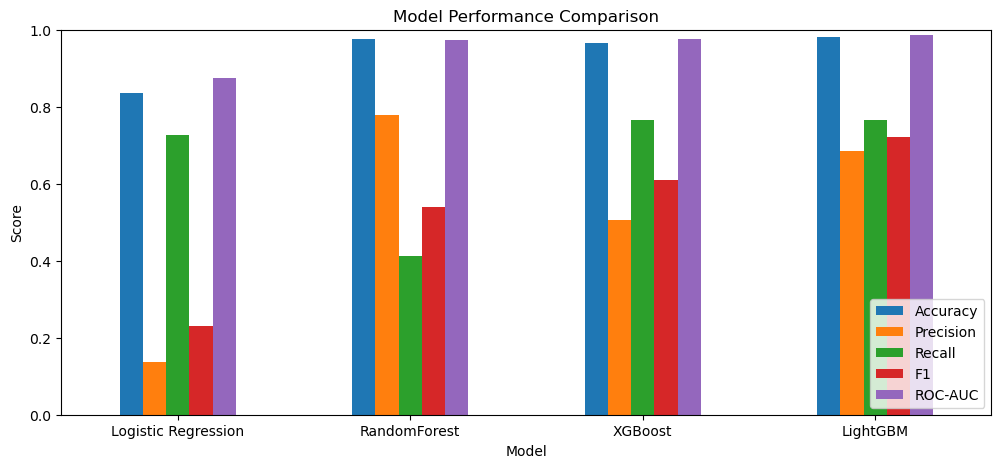

In [227]:
all_performance_plot_df = all_result_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

ax = all_performance_plot_df.plot(kind="bar", figsize=(12, 5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")

plt.savefig(FIGURE_DIR / "all_model_performance_comparison.png", bbox_inches="tight")
plt.show()

## 전체 모델 성능 비교 그래프 해석

전체 모델 성능 비교 그래프를 통해 모델별 성능 차이를 시각적으로 확인하였다.

LightGBM은 Accuracy, F1-score, ROC-AUC에서 가장 높은 성능을 보였다.

XGBoost는 LightGBM과 동일한 Recall을 보였지만 Precision이 낮아 F1-score가 LightGBM보다 낮게 나타났다.

RandomForest는 Precision은 높았지만 Recall이 낮아 실제 고장을 놓치는 경우가 많았다.

Logistic Regression은 baseline 모델로서 Recall은 높았지만 Precision과 F1-score가 낮아 최종 모델로 선택하기에는 한계가 있었다.

따라서 검증 데이터 기준으로는 LightGBM을 최종 모델 후보로 선택한다.

In [228]:
best_model_row = all_result_df.sort_values(by="F1", ascending=False).iloc[0]

best_model_row

Model        LightGBM
Accuracy         0.98
Precision    0.684211
Recall       0.764706
F1           0.722222
ROC-AUC      0.987321
Name: 3, dtype: object

## 최종 후보 모델 선정

전체 모델 성능 비교 결과, LightGBM이 F1-score와 ROC-AUC에서 가장 높은 성능을 보였다.

LightGBM은 실제 고장 탐지율인 Recall을 높게 유지하면서도 XGBoost보다 Precision이 높아, Precision과 Recall의 균형이 가장 우수하였다.

따라서 본 프로젝트에서는 검증 데이터 기준 F1-score를 주요 기준으로 하여 LightGBM을 최종 후보 모델로 선정한다.

다음 단계에서는 LightGBM 모델을 test 데이터에서 최종 평가한다.

# 13. 최종 모델 선택 및 Test 평가

검증 데이터 기준 전체 모델 성능 비교 결과, LightGBM 모델이 F1-score와 ROC-AUC에서 가장 높은 성능을 보였다.

따라서 본 프로젝트에서는 LightGBM을 최종 모델로 선택한다.

이 단계에서는 모델 학습과 검증 과정에 사용하지 않은 test 데이터를 사용하여 최종 모델의 일반화 성능을 평가한다.

- train 데이터: 모델 학습
- valid 데이터: 모델 비교 및 선택
- test 데이터: 최종 성능 평가

In [229]:
best_model_name = all_result_df.sort_values(by="F1", ascending=False).iloc[0]["Model"]

model_dict = {
    "Logistic Regression": log_model,
    "RandomForest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

best_model = model_dict[best_model_name]

best_model_name

'LightGBM'

In [230]:
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

In [231]:
test_result = evaluate_model(best_model, X_test, y_test)

test_result

{'Accuracy': 0.9833333333333333,
 'Precision': 0.75,
 'Recall': 0.7647058823529411,
 'F1': 0.7572815533980582,
 'ROC-AUC': 0.966697790227202}

In [232]:
print_evaluation_report(best_model, X_test, y_test)

Confusion Matrix
[[1436   13]
 [  12   39]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1449
           1       0.75      0.76      0.76        51

    accuracy                           0.98      1500
   macro avg       0.87      0.88      0.87      1500
weighted avg       0.98      0.98      0.98      1500

ROC-AUC: 0.966697790227202


In [233]:
test_result_df = pd.DataFrame([test_result])
test_result_df.insert(0, "Model", best_model_name)

test_result_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM,0.983333,0.75,0.764706,0.757282,0.966698


In [234]:
cm = confusion_matrix(y_test, y_test_pred)

cm

array([[1436,   13],
       [  12,   39]])

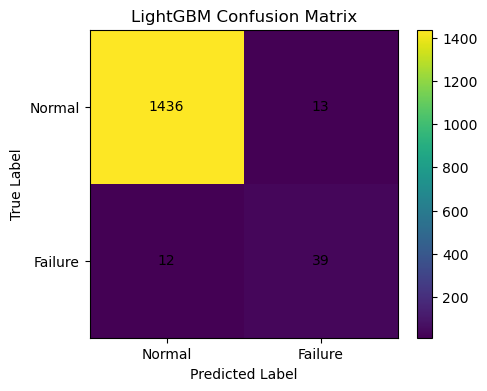

PosixPath('../figures/confusion_matrix_lightgbm.png')

In [235]:
safe_model_name = best_model_name.lower().replace(" ", "_")

confusion_matrix_path = FIGURE_DIR / f"confusion_matrix_{safe_model_name}.png"

plt.figure(figsize=(5, 4))

plt.imshow(cm)
plt.title(f"{best_model_name} Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Normal", "Failure"])
plt.yticks([0, 1], ["Normal", "Failure"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.savefig(confusion_matrix_path, bbox_inches="tight")
plt.show()

confusion_matrix_path

## Test 데이터 최종 평가 결과

검증 데이터 기준으로 가장 우수한 성능을 보인 LightGBM 모델을 최종 모델로 선택하였다.

최종 모델은 모델 학습과 검증 과정에 사용하지 않은 test 데이터에서 평가하였다.

Test 데이터 기준 성능은 다음과 같다.

* Accuracy: 0.983
* Precision: 0.750
* Recall: 0.765
* F1-score: 0.757
* ROC-AUC: 0.967

Confusion Matrix를 확인한 결과, 실제 정상 1449개 중 1436개를 정상으로 정확히 예측하였고, 13개는 고장으로 잘못 예측하였다.

실제 고장 51개 중 39개를 고장으로 탐지하였고, 12개는 정상으로 잘못 예측하였다.

LightGBM 모델은 실제 고장의 약 76.5%를 탐지하였으며, 고장이라고 예측한 경우 실제 고장일 비율도 75.0%로 나타났다.

이는 최종 모델이 고장 탐지율과 고장 예측 신뢰도 사이에서 비교적 균형 잡힌 성능을 보였다는 것을 의미한다.

기존 RandomForest 모델은 Precision은 높았지만 Recall이 낮아 실제 고장을 놓치는 경우가 많았다. 반면 LightGBM은 Precision을 일정 수준 유지하면서 Recall을 크게 개선하였다.

따라서 본 프로젝트에서는 test 데이터 기준 F1-score가 0.757로 나타난 LightGBM을 최종 모델로 선정하였다.

다음 단계에서는 최종 LightGBM 모델의 Feature Importance를 분석하여 고장 예측에 영향을 많이 준 주요 변수를 확인한다.


# 14. Feature Importance 분석

최종 모델로 선택한 LightGBM 모델의 Feature Importance를 확인한다.

Feature Importance는 모델이 예측을 수행할 때 각 feature를 얼마나 중요하게 사용했는지를 나타낸다.

이를 통해 제조 설비 고장 예측에 영향을 많이 준 주요 변수를 확인할 수 있다.

In [236]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
3,torque,2328
4,tool_wear,1994
2,rot_speed,1655
0,air_temp,1425
1,process_temp,1399
6,type_M,108
5,type_L,91


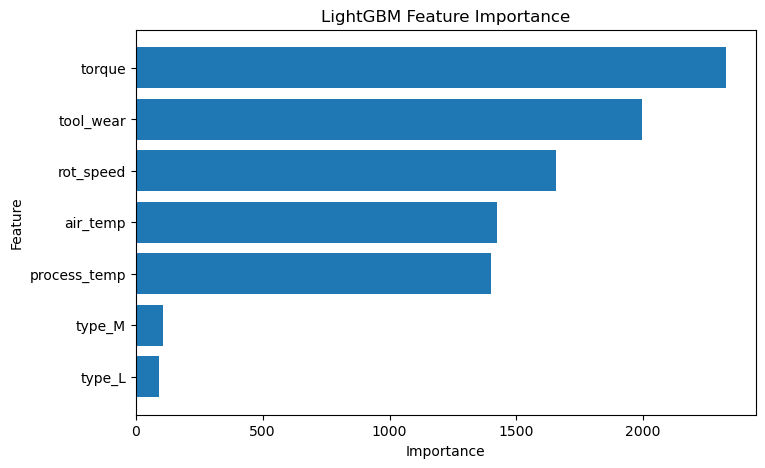

PosixPath('../figures/feature_importance_lightgbm.png')

In [237]:
feature_importance_path = FIGURE_DIR / "feature_importance_lightgbm.png"

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importance")

plt.savefig(feature_importance_path, bbox_inches="tight")
plt.show()

feature_importance_path

## Feature Importance 분석 결과

최종 모델로 선택한 LightGBM 모델의 Feature Importance를 확인하였다.

Feature Importance 분석 결과, `torque`, `tool_wear`, `rot_speed`가 고장 예측에 가장 중요한 변수로 나타났다.

가장 높은 중요도를 보인 변수는 `torque`였으며, importance 값은 2328이었다.  
그다음으로 `tool_wear`가 1994, `rot_speed`가 1655로 나타났다.

이 세 변수는 제조 설비의 작동 상태와 직접적으로 관련된 변수이다.

- `torque`: 설비에 걸리는 부하
- `tool_wear`: 공구의 누적 마모 정도
- `rot_speed`: 설비의 회전 속도

Phase 1 EDA에서도 고장 데이터는 정상 데이터와 비교했을 때 높은 토크, 높은 공구 마모 시간, 낮은 회전 속도와 관련되는 경향을 보였다.  
최종 LightGBM 모델의 Feature Importance에서도 이 변수들이 상위 feature로 나타나, EDA에서 확인한 패턴이 모델 학습 결과와도 연결됨을 확인할 수 있었다.

`air_temp`와 `process_temp`도 일정 수준의 중요도를 보였지만, 상위 세 변수보다는 낮게 나타났다.

반면 제품 유형을 나타내는 `type_M`, `type_L`의 중요도는 상대적으로 낮았다.  
이는 최종 모델이 제품 유형보다는 센서 기반 작동 조건을 고장 예측에 더 중요하게 활용했음을 의미한다.

다만 Feature Importance는 각 feature가 모델에 얼마나 많이 활용되었는지를 보여줄 뿐, 해당 feature 값이 증가할수록 고장 가능성이 증가하는지 또는 감소하는지는 직접적으로 설명하지 않는다.

따라서 향후 SHAP 분석을 추가하면 각 feature가 예측 결과에 미치는 방향성과 개별 예측에 대한 영향을 더 자세히 해석할 수 있다.

# 15. 모델 저장

최종 모델로 선택한 LightGBM 모델을 저장한다.

저장된 모델은 이후 다시 불러와서 예측에 사용할 수 있다.

이번 프로젝트에서는 `joblib`을 사용하여 모델을 `.pkl` 파일로 저장한다.

모델 파일은 `models` 폴더에 저장되며, `.gitignore` 설정에 따라 GitHub에는 업로드하지 않는다.

In [238]:
import joblib

In [239]:
model_path = MODEL_DIR / "lightgbm_binary_model.pkl"

joblib.dump(best_model, model_path)

model_path

PosixPath('../models/lightgbm_binary_model.pkl')

In [240]:
loaded_model = joblib.load(model_path)

loaded_model

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [241]:
loaded_test_result = evaluate_model(loaded_model, X_test, y_test)

loaded_test_result

{'Accuracy': 0.9833333333333333,
 'Precision': 0.75,
 'Recall': 0.7647058823529411,
 'F1': 0.7572815533980582,
 'ROC-AUC': 0.966697790227202}

In [242]:
feature_columns = pd.DataFrame({
    "feature": X_train.columns
})

feature_columns.to_csv(REPORT_DIR / "feature_columns.csv", index=False)

feature_columns

,feature
0,air_temp
1,process_temp
2,rot_speed
3,torque
4,tool_wear
5,type_L
6,type_M


In [243]:
test_result_df.to_csv(REPORT_DIR / "final_model_test_result.csv", index=False)

test_result_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM,0.983333,0.75,0.764706,0.757282,0.966698


## 모델 저장 결과

최종 모델로 선택한 LightGBM 모델을 `lightgbm_binary_model.pkl` 파일로 저장하였다.

저장된 모델을 다시 불러온 뒤 test 데이터에 대해 예측을 수행하여, 모델 저장과 로드가 정상적으로 동작하는 것을 확인하였다.

또한 이후 모델 재사용을 위해 학습에 사용된 feature 컬럼 목록을 `feature_columns.csv`로 저장하였다.

최종 test 성능 결과는 `final_model_test_result.csv` 파일로 저장하였다.

모델 파일인 `.pkl` 파일은 용량이 커질 수 있으므로 `.gitignore` 설정에 따라 GitHub에는 업로드하지 않는다.  
대신 모델을 학습하고 저장하는 코드를 노트북에 포함하여 재현 가능하도록 구성하였다.

# 16. SHAP 분석

최종 후보 모델인 LightGBM 모델에 대해 SHAP 분석을 수행한다.

SHAP은 모델의 예측 결과에 각 feature가 어떤 영향을 주었는지 설명하는 모델 해석 기법이다.

기존 Feature Importance는 모델이 어떤 feature를 중요하게 사용했는지만 보여주지만, SHAP은 각 feature가 예측값을 증가시키는 방향으로 작용했는지 또는 감소시키는 방향으로 작용했는지를 확인할 수 있다.

이번 단계에서는 validation 데이터를 기준으로 SHAP 값을 계산하여 LightGBM 모델이 고장 예측에 어떤 feature를 중요하게 활용했는지 분석한다.


In [244]:
import shap
import numpy as np

In [245]:
shap_explainer = shap.TreeExplainer(best_model)

shap_values = shap_explainer.shap_values(X_valid)

if isinstance(shap_values, list):
    shap_values_class_1 = shap_values[1]
else:
    shap_values_class_1 = shap_values

shap_values_class_1.shape

/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


(1500, 7)

In [246]:
shap_importance = pd.DataFrame({
    "feature": X_valid.columns,
    "mean_abs_shap": np.abs(shap_values_class_1).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="mean_abs_shap",
    ascending=False
)

shap_importance

,feature,mean_abs_shap
3,torque,0.963609
4,tool_wear,0.859954
0,air_temp,0.827730
2,rot_speed,0.777309
1,process_temp,0.613236
5,type_L,0.188117
6,type_M,0.125819


In [247]:
shap_importance.to_csv(
    REPORT_DIR / "shap_importance_lightgbm.csv",
    index=False
)

REPORT_DIR / "shap_importance_lightgbm.csv"

PosixPath('../reports/shap_importance_lightgbm.csv')

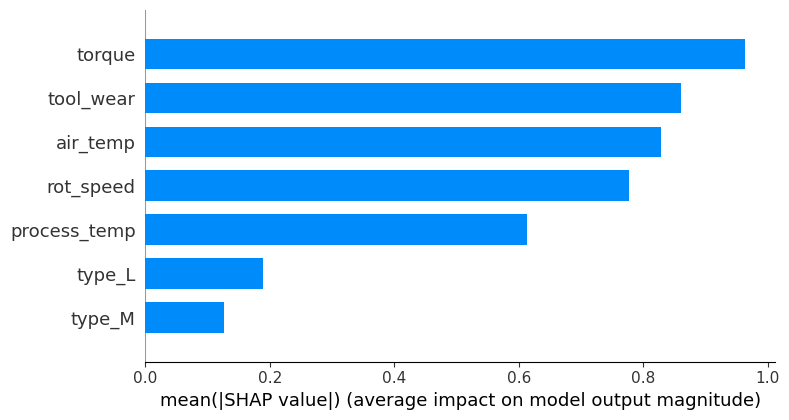

PosixPath('../figures/shap_bar_lightgbm.png')

In [248]:
shap_bar_path = FIGURE_DIR / "shap_bar_lightgbm.png"

plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_values_class_1,
    X_valid,
    plot_type="bar",
    feature_names=X_valid.columns,
    max_display=len(X_valid.columns),
    show=False
)

plt.savefig(shap_bar_path, bbox_inches="tight")
plt.show()

shap_bar_path

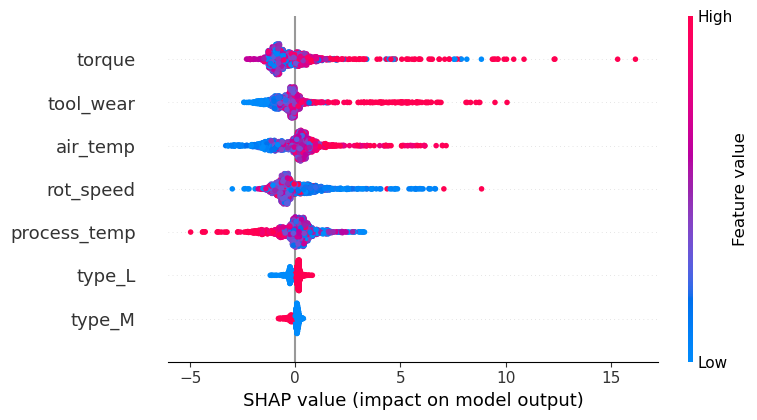

PosixPath('../figures/shap_summary_lightgbm.png')

In [249]:
shap_summary_path = FIGURE_DIR / "shap_summary_lightgbm.png"

plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_values_class_1,
    X_valid,
    feature_names=X_valid.columns,
    max_display=len(X_valid.columns),
    show=False
)

plt.savefig(shap_summary_path, bbox_inches="tight")
plt.show()

shap_summary_path

### SHAP Summary Plot 해석

SHAP Summary Plot을 통해 각 feature 값의 크기가 고장 예측에 어떤 방향으로 영향을 주는지 확인하였다.

x축의 SHAP value가 양수이면 고장 클래스 예측을 증가시키는 방향으로 작용하고, 음수이면 정상 클래스 예측을 증가시키는 방향으로 작용한다.
색상은 feature 값의 크기를 의미하며, 빨간색은 높은 값, 파란색은 낮은 값을 나타낸다.

분석 결과, `torque`는 값이 높을수록 양의 SHAP value를 가지는 경향이 나타났다.
따라서 torque가 높을수록 모델은 고장 가능성을 더 높게 판단하는 것으로 해석할 수 있다.

`tool_wear` 역시 값이 높을수록 양의 SHAP value를 가지는 경향을 보였다.
이는 공구 마모 시간이 증가할수록 모델이 고장 가능성을 더 높게 판단하는 경향이 있음을 의미한다.

`air_temp`는 SHAP 중요도 기준 상위 feature로 나타났으며, Summary Plot에서도 높은 값이 양의 SHAP value 쪽에 분포하는 경향을 보였다.
따라서 공기 온도가 높을수록 모델의 고장 예측을 증가시키는 방향으로 작용한다고 해석할 수 있다.

반면 `rot_speed`는 낮은 값이 양의 SHAP value 쪽에 분포하는 경향을 보였다.
이는 회전 속도가 낮을수록 모델이 고장 가능성을 더 높게 판단한다는 것을 의미한다.

`process_temp`는 다른 주요 변수에 비해 방향성이 단순하지 않게 나타났다.
높은 값과 낮은 값이 양의 SHAP value와 음의 SHAP value에 함께 분포하므로, process_temp 하나만으로 고장 방향성을 단정하기는 어렵다.

이는 `air_temp`와 `process_temp` 사이의 상관관계가 높기 때문에, 모델이 두 온도 feature를 독립적으로 보기보다는 함께 고려했을 가능성이 있다.
따라서 이후 Feature Engineering 단계에서는 `process_temp - air_temp`와 같은 온도 차이 feature를 추가하여 성능 변화를 확인할 필요가 있다.

제품 유형을 나타내는 `type_L`, `type_M`은 대부분 0 근처에 분포하였다.
이는 제품 유형 feature가 고장 예측에 미치는 영향이 상대적으로 작다는 것을 의미한다.

SHAP 분석 결과를 종합하면, LightGBM 모델은 높은 torque, 높은 tool_wear, 높은 air_temp, 낮은 rot_speed를 고장 예측의 주요 신호로 활용하고 있음을 확인할 수 있었다.

이 결과는 이후 Feature Engineering 단계에서 `torque`, `tool_wear`, `rot_speed`, `air_temp`, 온도 차이와 관련된 파생변수를 설계하는 근거로 활용할 수 있다.


# 17. Feature Engineering v1 - 연속형 조합 Feature 추가

EDA와 SHAP 분석 결과를 바탕으로 연속형 조합 feature를 추가한다.

* EDA: https://github.com/mjbaa/manufacturing-eda-project

이번 Feature Engineering은 단순히 임의로 feature를 추가한 것이 아니라, 다음 세 가지 기준을 바탕으로 설계하였다.

1. EDA에서 확인한 고장 데이터의 특징
2. SHAP 분석에서 확인한 feature 중요도와 영향 방향
3. 제조 설비 관점에서 해석 가능한 변수 조합

EDA에서는 고장 데이터가 정상 데이터에 비해 높은 `torque`, 높은 `tool_wear`, 낮은 `rot_speed`, 높은 `air_temp`와 관련되는 경향을 보였다.

또한 `rot_speed`와 `torque`는 강한 음의 상관관계를 보였고, `air_temp`와 `process_temp`는 강한 양의 상관관계를 보였다.

SHAP 분석에서도 `torque`, `tool_wear`, `air_temp`, `rot_speed`, `process_temp`가 고장 예측에 중요한 변수로 나타났다.

특히 SHAP Summary Plot에서는 높은 `torque`, 높은 `tool_wear`, 높은 `air_temp`, 낮은 `rot_speed`가 고장 예측을 증가시키는 방향으로 작용하는 경향을 확인하였다.

따라서 이번 단계에서는 주요 센서 변수 간의 관계를 반영하기 위해 다음 파생변수를 생성한다.

* `temp_diff`: 공정 온도와 공기 온도의 차이
* `torque_speed_ratio`: 토크와 회전 속도의 비율
* `wear_torque`: 공구 마모 시간과 토크의 조합
* `wear_speed_ratio`: 공구 마모 시간과 회전 속도의 비율
* `power_proxy`: 토크와 회전 속도의 곱
* `air_temp_torque`: 공기 온도와 토크의 조합

각 파생변수를 추가한 기준은 다음과 같다.

| Feature              | 생성 기준                                                                     |
| -------------------- | ------------------------------------------------------------------------- |
| `temp_diff`          | `air_temp`와 `process_temp`의 상관관계가 높고, 두 온도 변수의 차이가 고장 예측에 의미가 있을 수 있다고 판단 |
| `torque_speed_ratio` | 고장 데이터에서 높은 `torque`와 낮은 `rot_speed` 경향이 확인되어, 회전 속도 대비 토크 수준을 표현         |
| `wear_torque`        | 높은 `tool_wear`와 높은 `torque`가 함께 나타나는 상태를 반영                               |
| `wear_speed_ratio`   | 높은 `tool_wear`와 낮은 `rot_speed` 조합을 반영                                     |
| `power_proxy`        | `torque`와 `rot_speed`를 함께 사용하여 설비의 작업 부하를 근사적으로 표현                        |
| `air_temp_torque`    | 높은 `air_temp`와 높은 `torque`가 동시에 나타나는 조건을 반영                               |

즉, 이번에 추가한 feature들은 고장과 관련 있는 단일 변수들을 조합하여 모델이 주요 고장 패턴을 더 쉽게 학습할 수 있도록 설계한 것이다.

이번 실험에서는 기존 LightGBM 모델과 동일한 하이퍼파라미터를 사용한다.

따라서 성능 변화는 주로 feature engineering의 영향으로 해석할 수 있다.

모델 비교는 validation 데이터 기준으로 수행하며, test 데이터는 최종 모델이 확정된 이후 마지막 평가에만 사용한다.


In [250]:
experiment_results = []

baseline_result = lgbm_valid_result.copy()
baseline_result["Experiment"] = "LightGBM_baseline"

experiment_results.append(baseline_result)

experiment_results_df = pd.DataFrame(experiment_results)

experiment_results_df = experiment_results_df[
    ["Experiment", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

experiment_results_df

,Experiment,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM_baseline,0.98,0.684211,0.764706,0.722222,0.987321


In [251]:
def add_continuous_engineered_features(X):
    X_new = X.copy()
    
    epsilon = 1e-6
    
    X_new["temp_diff"] = X_new["process_temp"] - X_new["air_temp"]
    X_new["torque_speed_ratio"] = X_new["torque"] / (X_new["rot_speed"] + epsilon)
    X_new["wear_torque"] = X_new["tool_wear"] * X_new["torque"]
    X_new["wear_speed_ratio"] = X_new["tool_wear"] / (X_new["rot_speed"] + epsilon)
    X_new["power_proxy"] = X_new["torque"] * X_new["rot_speed"]
    X_new["air_temp_torque"] = X_new["air_temp"] * X_new["torque"]
    
    return X_new

In [252]:
X_train_fe_v1 = add_continuous_engineered_features(X_train)
X_valid_fe_v1 = add_continuous_engineered_features(X_valid)
X_test_fe_v1 = add_continuous_engineered_features(X_test)

In [253]:
print("Before Feature Engineering:", X_train.shape)
print("After Feature Engineering:", X_train_fe_v1.shape)

Before Feature Engineering: (7000, 7)
After Feature Engineering: (7000, 13)


In [254]:
new_features_v1 = [
    col for col in X_train_fe_v1.columns
    if col not in X_train.columns
]

new_features_v1

['temp_diff',
 'torque_speed_ratio',
 'wear_torque',
 'wear_speed_ratio',
 'power_proxy',
 'air_temp_torque']

In [255]:
lgbm_fe_v1_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgbm_fe_v1_model.fit(X_train_fe_v1, y_train)

[LightGBM] [Info] Number of positive: 237, number of negative: 6763
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2283
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [256]:
lgbm_fe_v1_valid_result = evaluate_model(
    lgbm_fe_v1_model,
    X_valid_fe_v1,
    y_valid
)

lgbm_fe_v1_valid_result

{'Accuracy': 0.9906666666666667,
 'Precision': 0.8775510204081632,
 'Recall': 0.8431372549019608,
 'F1': 0.86,
 'ROC-AUC': 0.9822189745463402}

In [257]:
print_evaluation_report(
    lgbm_fe_v1_model,
    X_valid_fe_v1,
    y_valid
)

Confusion Matrix
[[1443    6]
 [   8   43]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1449
           1       0.88      0.84      0.86        51

    accuracy                           0.99      1500
   macro avg       0.94      0.92      0.93      1500
weighted avg       0.99      0.99      0.99      1500

ROC-AUC: 0.9822189745463402


In [258]:
fe_v1_result = lgbm_fe_v1_valid_result.copy()
fe_v1_result["Experiment"] = "LightGBM_FE_v1_continuous"

experiment_results.append(fe_v1_result)

experiment_results_df = pd.DataFrame(experiment_results)

experiment_results_df = experiment_results_df[
    ["Experiment", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

experiment_results_df

,Experiment,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM_baseline,0.980000,0.684211,0.764706,0.722222,0.987321
1,LightGBM_FE_v1_continuous,0.990667,0.877551,0.843137,0.860000,0.982219


In [259]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

comparison_from_baseline_df = experiment_results_df.copy()

baseline_values = comparison_from_baseline_df.loc[
    comparison_from_baseline_df["Experiment"] == "LightGBM_baseline",
    metrics
].iloc[0]

for metric in metrics:
    comparison_from_baseline_df[f"{metric}_diff_from_baseline"] = (
        comparison_from_baseline_df[metric] - baseline_values[metric]
    )

comparison_from_baseline_df

,Experiment,Accuracy,Precision,Recall,F1,ROC-AUC,Accuracy_diff_from_baseline,Precision_diff_from_baseline,Recall_diff_from_baseline,F1_diff_from_baseline,ROC-AUC_diff_from_baseline
0,LightGBM_baseline,0.980000,0.684211,0.764706,0.722222,0.987321,0.000000,0.00000,0.000000,0.000000,0.000000
1,LightGBM_FE_v1_continuous,0.990667,0.877551,0.843137,0.860000,0.982219,0.010667,0.19334,0.078431,0.137778,-0.005102


In [260]:
comparison_from_previous_df = experiment_results_df.copy()

for metric in metrics:
    comparison_from_previous_df[f"{metric}_diff_from_previous"] = (
        comparison_from_previous_df[metric].diff()
    )

comparison_from_previous_df

,Experiment,Accuracy,Precision,Recall,F1,ROC-AUC,Accuracy_diff_from_previous,Precision_diff_from_previous,Recall_diff_from_previous,F1_diff_from_previous,ROC-AUC_diff_from_previous
0,LightGBM_baseline,0.980000,0.684211,0.764706,0.722222,0.987321,NaN,NaN,NaN,NaN,NaN
1,LightGBM_FE_v1_continuous,0.990667,0.877551,0.843137,0.860000,0.982219,0.010667,0.19334,0.078431,0.137778,-0.005102


In [261]:
experiment_results_df.to_csv(
    REPORT_DIR / "experiment_results.csv",
    index=False
)

comparison_from_baseline_df.to_csv(
    REPORT_DIR / "experiment_comparison_from_baseline.csv",
    index=False
)

comparison_from_previous_df.to_csv(
    REPORT_DIR / "experiment_comparison_from_previous.csv",
    index=False
)

## Feature Engineering v1 결과

EDA와 SHAP 분석 결과를 바탕으로 연속형 조합 feature를 추가하였다.

추가한 feature는 다음과 같다.

* `temp_diff`
* `torque_speed_ratio`
* `wear_torque`
* `wear_speed_ratio`
* `power_proxy`
* `air_temp_torque`

기존 LightGBM 모델과 동일한 하이퍼파라미터를 사용하여 feature engineering의 효과를 확인하였다.

Validation 데이터 기준 성능 비교 결과는 다음과 같다.

| Experiment                | Accuracy | Precision | Recall | F1-score | ROC-AUC |
| ------------------------- | -------: | --------: | -----: | -------: | ------: |
| LightGBM_baseline         |    0.980 |     0.684 |  0.765 |    0.722 |   0.987 |
| LightGBM_FE_v1_continuous |    0.991 |     0.878 |  0.843 |    0.860 |   0.982 |

Feature Engineering v1 적용 후 기존 LightGBM baseline 대비 성능 변화는 다음과 같다.

* Accuracy 변화: +0.0107
* Precision 변화: +0.1933
* Recall 변화: +0.0784
* F1-score 변화: +0.1378
* ROC-AUC 변화: -0.0051

Confusion Matrix를 비교하면, 기존 LightGBM baseline은 실제 정상 1449개 중 18개를 고장으로 잘못 예측하였고, 실제 고장 51개 중 12개를 정상으로 잘못 예측하였다.

반면 Feature Engineering v1 모델은 실제 정상 1449개 중 6개만 고장으로 잘못 예측하였고, 실제 고장 51개 중 8개를 정상으로 잘못 예측하였다.

즉, Feature Engineering v1 적용 후 정상 데이터를 고장으로 잘못 예측한 경우는 18개에서 6개로 감소하였고, 실제 고장을 놓친 경우는 12개에서 8개로 감소하였다.

이는 연속형 조합 feature가 모델의 고장 탐지 성능과 예측 신뢰도를 모두 개선하는 데 도움이 되었음을 의미한다.

특히 F1-score가 0.722에서 0.860으로 크게 상승하였고, Precision과 Recall이 모두 개선되었다.

ROC-AUC는 0.987에서 0.982로 소폭 감소하였지만, 실제 분류 결과에서 Precision, Recall, F1-score가 모두 개선되었기 때문에 Feature Engineering v1은 유효한 개선으로 판단하였다.

따라서 이후 실험에서는 Feature Engineering v1을 유지한 상태에서 구간 indicator feature를 추가하는 v2 실험을 진행한다.


# 18. Feature Engineering v2 - 구간 Indicator Feature 추가

Feature Engineering v1에서는 EDA와 SHAP 분석 결과를 바탕으로 연속형 조합 feature를 추가하였다.

이번 단계에서는 v1 feature를 유지한 상태에서 구간 indicator feature를 추가한다.

구간 indicator feature는 특정 feature 값이 위험 구간에 해당하는지를 0 또는 1로 표현한 변수이다.

EDA와 SHAP 분석에서 높은 `torque`, 높은 `tool_wear`, 높은 `air_temp`, 낮은 `rot_speed`가 고장 예측과 관련되는 경향을 보였다.

따라서 다음과 같은 indicator feature를 추가한다.

* `high_torque`: torque가 높은 구간이면 1
* `high_tool_wear`: tool_wear가 높은 구간이면 1
* `high_air_temp`: air_temp가 높은 구간이면 1
* `low_rot_speed`: rot_speed가 낮은 구간이면 1

구간 기준은 전체 데이터가 아니라 train 데이터의 분위수를 기준으로 설정한다.

이는 validation 데이터와 test 데이터의 정보를 feature 생성 과정에 사용하지 않기 위해서이다.

이번 실험에서도 기존 LightGBM 모델과 동일한 하이퍼파라미터를 사용한다.

모델 성능은 validation 데이터 기준으로 비교하며, Feature Engineering v2가 baseline 및 v1 대비 성능을 개선했는지 확인한다.


In [262]:
indicator_thresholds = {
    "high_torque": X_train["torque"].quantile(0.75),
    "high_tool_wear": X_train["tool_wear"].quantile(0.75),
    "high_air_temp": X_train["air_temp"].quantile(0.75),
    "low_rot_speed": X_train["rot_speed"].quantile(0.25)
}

indicator_thresholds

{'high_torque': np.float64(46.8),
 'high_tool_wear': np.float64(163.0),
 'high_air_temp': np.float64(301.5),
 'low_rot_speed': np.float64(1423.0)}

In [263]:
def add_indicator_features(X, thresholds):
    X_new = X.copy()
    
    X_new["high_torque"] = (
        X_new["torque"] >= thresholds["high_torque"]
    ).astype(int)
    
    X_new["high_tool_wear"] = (
        X_new["tool_wear"] >= thresholds["high_tool_wear"]
    ).astype(int)
    
    X_new["high_air_temp"] = (
        X_new["air_temp"] >= thresholds["high_air_temp"]
    ).astype(int)
    
    X_new["low_rot_speed"] = (
        X_new["rot_speed"] <= thresholds["low_rot_speed"]
    ).astype(int)
    
    return X_new

In [264]:
X_train_fe_v2 = add_indicator_features(X_train_fe_v1, indicator_thresholds)
X_valid_fe_v2 = add_indicator_features(X_valid_fe_v1, indicator_thresholds)
X_test_fe_v2 = add_indicator_features(X_test_fe_v1, indicator_thresholds)

In [265]:
print("Original features:", X_train.shape)
print("After FE v1:", X_train_fe_v1.shape)
print("After FE v2:", X_train_fe_v2.shape)

Original features: (7000, 7)
After FE v1: (7000, 13)
After FE v2: (7000, 17)


In [266]:
new_features_v2 = [
    col for col in X_train_fe_v2.columns
    if col not in X_train_fe_v1.columns
]

new_features_v2

['high_torque', 'high_tool_wear', 'high_air_temp', 'low_rot_speed']

In [267]:
lgbm_fe_v2_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgbm_fe_v2_model.fit(X_train_fe_v2, y_train)

[LightGBM] [Info] Number of positive: 237, number of negative: 6763
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000344 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2291
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [268]:
lgbm_fe_v2_valid_result = evaluate_model(
    lgbm_fe_v2_model,
    X_valid_fe_v2,
    y_valid
)

lgbm_fe_v2_valid_result

{'Accuracy': 0.992,
 'Precision': 0.8979591836734694,
 'Recall': 0.8627450980392157,
 'F1': 0.88,
 'ROC-AUC': 0.9820024628208771}

In [269]:
print_evaluation_report(
    lgbm_fe_v2_model,
    X_valid_fe_v2,
    y_valid
)

Confusion Matrix
[[1444    5]
 [   7   44]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1449
           1       0.90      0.86      0.88        51

    accuracy                           0.99      1500
   macro avg       0.95      0.93      0.94      1500
weighted avg       0.99      0.99      0.99      1500

ROC-AUC: 0.9820024628208771


In [270]:
fe_v2_result = lgbm_fe_v2_valid_result.copy()
fe_v2_result["Experiment"] = "LightGBM_FE_v2_indicator"

experiment_results.append(fe_v2_result)

experiment_results_df = pd.DataFrame(experiment_results)

experiment_results_df = experiment_results_df[
    ["Experiment", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

experiment_results_df

,Experiment,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM_baseline,0.980000,0.684211,0.764706,0.722222,0.987321
1,LightGBM_FE_v1_continuous,0.990667,0.877551,0.843137,0.860000,0.982219
2,LightGBM_FE_v2_indicator,0.992000,0.897959,0.862745,0.880000,0.982002


In [271]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

comparison_from_baseline_df = experiment_results_df.copy()

baseline_values = comparison_from_baseline_df.loc[
    comparison_from_baseline_df["Experiment"] == "LightGBM_baseline",
    metrics
].iloc[0]

for metric in metrics:
    comparison_from_baseline_df[f"{metric}_diff_from_baseline"] = (
        comparison_from_baseline_df[metric] - baseline_values[metric]
    )

comparison_from_baseline_df

,Experiment,Accuracy,Precision,Recall,F1,ROC-AUC,Accuracy_diff_from_baseline,Precision_diff_from_baseline,Recall_diff_from_baseline,F1_diff_from_baseline,ROC-AUC_diff_from_baseline
0,LightGBM_baseline,0.980000,0.684211,0.764706,0.722222,0.987321,0.000000,0.000000,0.000000,0.000000,0.000000
1,LightGBM_FE_v1_continuous,0.990667,0.877551,0.843137,0.860000,0.982219,0.010667,0.193340,0.078431,0.137778,-0.005102
2,LightGBM_FE_v2_indicator,0.992000,0.897959,0.862745,0.880000,0.982002,0.012000,0.213749,0.098039,0.157778,-0.005318


In [272]:
comparison_from_previous_df = experiment_results_df.copy()

for metric in metrics:
    comparison_from_previous_df[f"{metric}_diff_from_previous"] = (
        comparison_from_previous_df[metric].diff()
    )

comparison_from_previous_df

,Experiment,Accuracy,Precision,Recall,F1,ROC-AUC,Accuracy_diff_from_previous,Precision_diff_from_previous,Recall_diff_from_previous,F1_diff_from_previous,ROC-AUC_diff_from_previous
0,LightGBM_baseline,0.980000,0.684211,0.764706,0.722222,0.987321,NaN,NaN,NaN,NaN,NaN
1,LightGBM_FE_v1_continuous,0.990667,0.877551,0.843137,0.860000,0.982219,0.010667,0.193340,0.078431,0.137778,-0.005102
2,LightGBM_FE_v2_indicator,0.992000,0.897959,0.862745,0.880000,0.982002,0.001333,0.020408,0.019608,0.020000,-0.000217


In [273]:
experiment_results_df.to_csv(
    REPORT_DIR / "experiment_results.csv",
    index=False
)

comparison_from_baseline_df.to_csv(
    REPORT_DIR / "experiment_comparison_from_baseline.csv",
    index=False
)

comparison_from_previous_df.to_csv(
    REPORT_DIR / "experiment_comparison_from_previous.csv",
    index=False
)

## Feature Engineering v2 결과

Feature Engineering v2에서는 v1에서 추가한 연속형 조합 feature를 유지한 상태에서 구간 indicator feature를 추가하였다.

추가한 indicator feature는 다음과 같다.

* `high_torque`
* `high_tool_wear`
* `high_air_temp`
* `low_rot_speed`

각 indicator feature의 기준값은 validation/test 데이터의 정보가 섞이지 않도록 train 데이터의 분위수를 기준으로 설정하였다.

Validation 데이터 기준 성능 비교 결과는 다음과 같다.

| Experiment                | Accuracy | Precision | Recall | F1-score | ROC-AUC |
| ------------------------- | -------: | --------: | -----: | -------: | ------: |
| LightGBM_baseline         |    0.980 |     0.684 |  0.765 |    0.722 |   0.987 |
| LightGBM_FE_v1_continuous |    0.991 |     0.878 |  0.843 |    0.860 |   0.982 |
| LightGBM_FE_v2_indicator  |    0.992 |     0.898 |  0.863 |    0.880 |   0.982 |

Feature Engineering v2 적용 후 baseline 대비 성능 변화는 다음과 같다.

* Accuracy 변화: +0.0120
* Precision 변화: +0.2137
* Recall 변화: +0.0980
* F1-score 변화: +0.1578
* ROC-AUC 변화: -0.0053

직전 실험인 Feature Engineering v1 대비 성능 변화는 다음과 같다.

* Accuracy 변화: +0.0013
* Precision 변화: +0.0204
* Recall 변화: +0.0196
* F1-score 변화: +0.0200
* ROC-AUC 변화: -0.0002

Confusion Matrix를 비교하면, Feature Engineering v1 모델은 실제 정상 1449개 중 6개를 고장으로 잘못 예측하였고, 실제 고장 51개 중 8개를 정상으로 잘못 예측하였다.

Feature Engineering v2 모델은 실제 정상 1449개 중 5개를 고장으로 잘못 예측하였고, 실제 고장 51개 중 7개를 정상으로 잘못 예측하였다.

즉, v2 적용 후 v1 대비 정상 오탐은 1개 감소하였고, 고장 미탐도 1개 감소하였다.

이는 구간 indicator feature가 연속형 조합 feature에 추가적인 성능 개선을 제공했음을 의미한다.

특히 Precision, Recall, F1-score가 모두 개선되었으므로, Feature Engineering v2는 유효한 개선으로 판단하였다.

ROC-AUC는 baseline 대비 소폭 감소하였지만, 실제 분류 결과에서 Precision, Recall, F1-score가 모두 개선되었기 때문에 현재 문제에서는 v2 feature set을 유지하는 것이 적절하다고 판단하였다.


# 19. Feature Engineering v3 - 조합 Indicator Feature 추가

Feature Engineering v2에서는 EDA와 SHAP 분석 결과를 바탕으로 구간 indicator feature를 추가하였다.

이번 단계에서는 v2 feature를 유지한 상태에서 여러 위험 조건이 동시에 발생하는지를 나타내는 조합 indicator feature를 추가한다.

EDA와 SHAP 분석에서 높은 `torque`, 높은 `tool_wear`, 높은 `air_temp`, 낮은 `rot_speed`가 고장 예측과 관련되는 경향을 보였다.

따라서 단일 위험 구간뿐만 아니라, 여러 위험 조건이 동시에 나타나는 경우를 feature로 표현한다.

이번 단계에서 추가하는 조합 indicator feature는 다음과 같다.

* `low_speed_high_torque`: 낮은 회전 속도와 높은 토크가 동시에 나타나는 경우
* `high_wear_high_torque`: 높은 공구 마모와 높은 토크가 동시에 나타나는 경우
* `high_air_high_torque`: 높은 공기 온도와 높은 토크가 동시에 나타나는 경우
* `high_wear_low_speed`: 높은 공구 마모와 낮은 회전 속도가 동시에 나타나는 경우

이번 실험에서도 기존 LightGBM 모델과 동일한 하이퍼파라미터를 사용한다.

모델 성능은 validation 데이터 기준으로 비교하며, Feature Engineering v3가 baseline, v1, v2 대비 성능을 개선했는지 확인한다.


In [274]:
def add_combination_indicator_features(X):
    X_new = X.copy()
    
    X_new["low_speed_high_torque"] = (
        (X_new["low_rot_speed"] == 1) &
        (X_new["high_torque"] == 1)
    ).astype(int)
    
    X_new["high_wear_high_torque"] = (
        (X_new["high_tool_wear"] == 1) &
        (X_new["high_torque"] == 1)
    ).astype(int)
    
    X_new["high_air_high_torque"] = (
        (X_new["high_air_temp"] == 1) &
        (X_new["high_torque"] == 1)
    ).astype(int)
    
    X_new["high_wear_low_speed"] = (
        (X_new["high_tool_wear"] == 1) &
        (X_new["low_rot_speed"] == 1)
    ).astype(int)
    
    return X_new

In [275]:
X_train_fe_v3 = add_combination_indicator_features(X_train_fe_v2)
X_valid_fe_v3 = add_combination_indicator_features(X_valid_fe_v2)
X_test_fe_v3 = add_combination_indicator_features(X_test_fe_v2)

In [276]:
print("Original features:", X_train.shape)
print("After FE v1:", X_train_fe_v1.shape)
print("After FE v2:", X_train_fe_v2.shape)
print("After FE v3:", X_train_fe_v3.shape)

Original features: (7000, 7)
After FE v1: (7000, 13)
After FE v2: (7000, 17)
After FE v3: (7000, 21)


In [277]:
new_features_v3 = [
    col for col in X_train_fe_v3.columns
    if col not in X_train_fe_v2.columns
]

new_features_v3

['low_speed_high_torque',
 'high_wear_high_torque',
 'high_air_high_torque',
 'high_wear_low_speed']

In [278]:
lgbm_fe_v3_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgbm_fe_v3_model.fit(X_train_fe_v3, y_train)

[LightGBM] [Info] Number of positive: 237, number of negative: 6763
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2299
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [279]:
lgbm_fe_v3_valid_result = evaluate_model(
    lgbm_fe_v3_model,
    X_valid_fe_v3,
    y_valid
)

lgbm_fe_v3_valid_result

{'Accuracy': 0.99,
 'Precision': 0.86,
 'Recall': 0.8431372549019608,
 'F1': 0.8514851485148515,
 'ROC-AUC': 0.9816235673013167}

In [280]:
print_evaluation_report(
    lgbm_fe_v3_model,
    X_valid_fe_v3,
    y_valid
)

Confusion Matrix
[[1442    7]
 [   8   43]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1449
           1       0.86      0.84      0.85        51

    accuracy                           0.99      1500
   macro avg       0.93      0.92      0.92      1500
weighted avg       0.99      0.99      0.99      1500

ROC-AUC: 0.9816235673013167


In [281]:
fe_v3_result = lgbm_fe_v3_valid_result.copy()
fe_v3_result["Experiment"] = "LightGBM_FE_v3_combination_indicator"

experiment_results.append(fe_v3_result)

experiment_results_df = pd.DataFrame(experiment_results)

experiment_results_df = experiment_results_df[
    ["Experiment", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

experiment_results_df

,Experiment,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM_baseline,0.980000,0.684211,0.764706,0.722222,0.987321
1,LightGBM_FE_v1_continuous,0.990667,0.877551,0.843137,0.860000,0.982219
2,LightGBM_FE_v2_indicator,0.992000,0.897959,0.862745,0.880000,0.982002
3,LightGBM_FE_v3_combination_indicator,0.990000,0.860000,0.843137,0.851485,0.981624


In [282]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

comparison_from_baseline_df = experiment_results_df.copy()

baseline_values = comparison_from_baseline_df.loc[
    comparison_from_baseline_df["Experiment"] == "LightGBM_baseline",
    metrics
].iloc[0]

for metric in metrics:
    comparison_from_baseline_df[f"{metric}_diff_from_baseline"] = (
        comparison_from_baseline_df[metric] - baseline_values[metric]
    )

comparison_from_baseline_df

,Experiment,Accuracy,Precision,Recall,F1,ROC-AUC,Accuracy_diff_from_baseline,Precision_diff_from_baseline,Recall_diff_from_baseline,F1_diff_from_baseline,ROC-AUC_diff_from_baseline
0,LightGBM_baseline,0.980000,0.684211,0.764706,0.722222,0.987321,0.000000,0.000000,0.000000,0.000000,0.000000
1,LightGBM_FE_v1_continuous,0.990667,0.877551,0.843137,0.860000,0.982219,0.010667,0.193340,0.078431,0.137778,-0.005102
2,LightGBM_FE_v2_indicator,0.992000,0.897959,0.862745,0.880000,0.982002,0.012000,0.213749,0.098039,0.157778,-0.005318
3,LightGBM_FE_v3_combination_indicator,0.990000,0.860000,0.843137,0.851485,0.981624,0.010000,0.175789,0.078431,0.129263,-0.005697


In [283]:
comparison_from_previous_df = experiment_results_df.copy()

for metric in metrics:
    comparison_from_previous_df[f"{metric}_diff_from_previous"] = (
        comparison_from_previous_df[metric].diff()
    )

comparison_from_previous_df

,Experiment,Accuracy,Precision,Recall,F1,ROC-AUC,Accuracy_diff_from_previous,Precision_diff_from_previous,Recall_diff_from_previous,F1_diff_from_previous,ROC-AUC_diff_from_previous
0,LightGBM_baseline,0.980000,0.684211,0.764706,0.722222,0.987321,NaN,NaN,NaN,NaN,NaN
1,LightGBM_FE_v1_continuous,0.990667,0.877551,0.843137,0.860000,0.982219,0.010667,0.193340,0.078431,0.137778,-0.005102
2,LightGBM_FE_v2_indicator,0.992000,0.897959,0.862745,0.880000,0.982002,0.001333,0.020408,0.019608,0.020000,-0.000217
3,LightGBM_FE_v3_combination_indicator,0.990000,0.860000,0.843137,0.851485,0.981624,-0.002000,-0.037959,-0.019608,-0.028515,-0.000379


In [284]:
experiment_results_df.to_csv(
    REPORT_DIR / "experiment_results.csv",
    index=False
)

comparison_from_baseline_df.to_csv(
    REPORT_DIR / "experiment_comparison_from_baseline.csv",
    index=False
)

comparison_from_previous_df.to_csv(
    REPORT_DIR / "experiment_comparison_from_previous.csv",
    index=False
)

## Feature Engineering v3 결과

Feature Engineering v3에서는 v2에서 추가한 구간 indicator feature를 유지한 상태에서 조합 indicator feature를 추가하였다.

추가한 조합 indicator feature는 다음과 같다.

* `low_speed_high_torque`
* `high_wear_high_torque`
* `high_air_high_torque`
* `high_wear_low_speed`

이 feature들은 EDA와 SHAP 분석에서 확인한 주요 위험 신호가 동시에 발생하는 경우를 표현하기 위해 생성하였다.

Validation 데이터 기준 성능 비교 결과는 다음과 같다.

| Experiment                           | Accuracy | Precision | Recall | F1-score | ROC-AUC |
| ------------------------------------ | -------: | --------: | -----: | -------: | ------: |
| LightGBM_baseline                    |    0.980 |     0.684 |  0.765 |    0.722 |   0.987 |
| LightGBM_FE_v1_continuous            |    0.991 |     0.878 |  0.843 |    0.860 |   0.982 |
| LightGBM_FE_v2_indicator             |    0.992 |     0.898 |  0.863 |    0.880 |   0.982 |
| LightGBM_FE_v3_combination_indicator |    0.990 |     0.860 |  0.843 |    0.851 |   0.982 |

Feature Engineering v3 적용 후 직전 실험인 v2 대비 성능 변화는 다음과 같다.

* Accuracy 변화: -0.0020
* Precision 변화: -0.0380
* Recall 변화: -0.0196
* F1-score 변화: -0.0285
* ROC-AUC 변화: -0.0004

v3에서는 v2 대비 모든 주요 지표가 하락하였다.

특히 Precision은 0.898에서 0.860으로 감소하였고, Recall은 0.863에서 0.843으로 감소하였다.
이에 따라 F1-score도 0.880에서 0.851로 하락하였다.

이는 조합 indicator feature가 기존 v1, v2 feature set에 추가적인 성능 개선을 제공하지 못했음을 의미한다.

또한 LightGBM은 tree 기반 모델이므로 feature 간 조건 조합을 모델 내부에서 어느 정도 학습할 수 있다.
따라서 수동으로 추가한 조합 indicator feature가 기존 feature와 중복되거나 불필요한 노이즈로 작용했을 가능성이 있다.

성능과 feature set의 단순성을 함께 고려했을 때, v3 feature set보다는 v2 feature set을 유지하는 것이 더 적절하다고 판단하였다.

따라서 이후 하이퍼파라미터 튜닝 단계에서는 validation 기준 F1-score가 가장 높은 `LightGBM_FE_v2_indicator` 모델을 기준으로 진행한다.
